In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import parse_slurm as ps
import data_analysis as da
import glob
import pandas as pd

In [3]:
metric = 'AveRSS'

# Docking Protein-Protein Memory Analysis 

In [4]:
dpp = pd.read_csv('./data/clean/data_dpp.csv')
dpp_mem = dpp[['AveRSS', 'NCPUS']]

## Descriptive Analysis

In [5]:
for x in [4, 8, 16, 32]:
    group = ps.get_group(dpp_mem, ncpus=x)
    print(group.describe())

          AveRSS  NCPUS
count  13.000000   13.0
mean    0.688463    4.0
std     0.012373    0.0
min     0.673008    4.0
25%     0.675336    4.0
50%     0.691588    4.0
75%     0.693476    4.0
max     0.709528    4.0
          AveRSS  NCPUS
count  16.000000   16.0
mean    1.194457    8.0
std     0.009454    0.0
min     1.181544    8.0
25%     1.188050    8.0
50%     1.193000    8.0
75%     1.201929    8.0
max     1.212244    8.0
          AveRSS  NCPUS
count  10.000000   10.0
mean    2.219257   16.0
std     0.006195    0.0
min     2.207268   16.0
25%     2.215786   16.0
50%     2.220070   16.0
75%     2.222774   16.0
max     2.228660   16.0
          AveRSS  NCPUS
count  13.000000   13.0
mean    3.919600   32.0
std     0.053626    0.0
min     3.877588   32.0
25%     3.890256   32.0
50%     3.915472   32.0
75%     3.916520   32.0
max     4.085656   32.0


## Boxplots

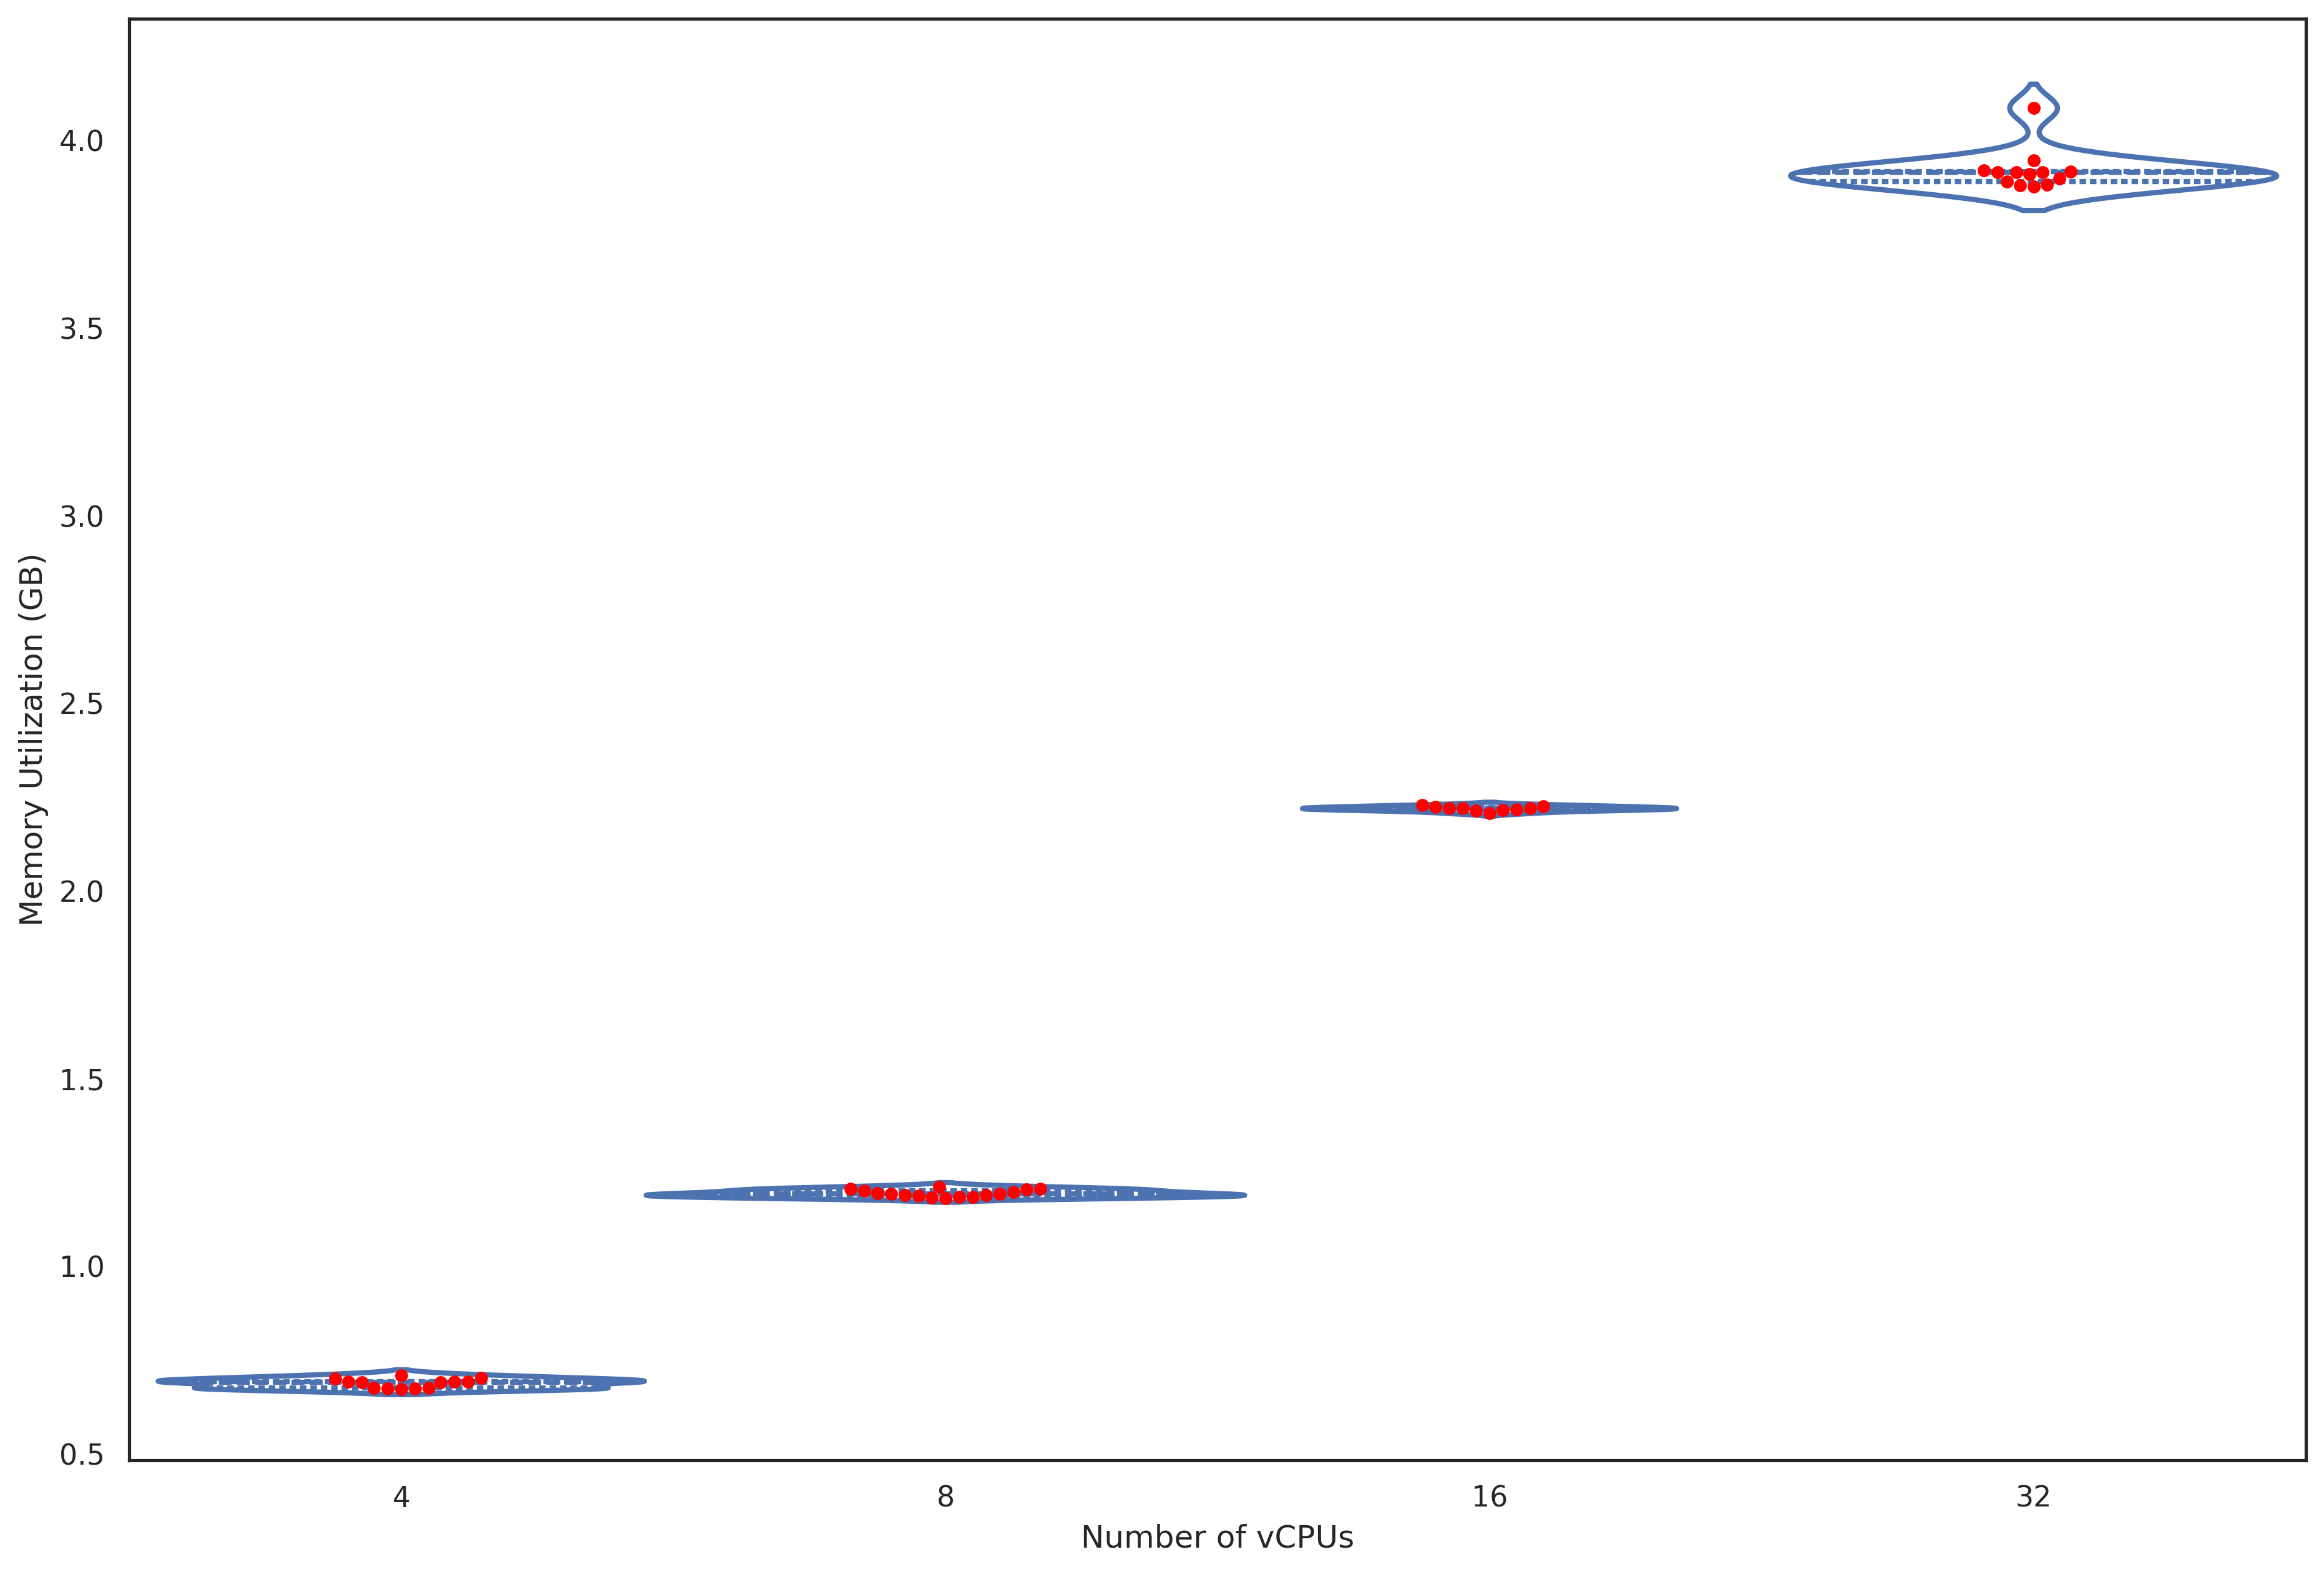

In [6]:
da.show_boxplot(
    dpp_mem, "Average Memory (Resident Set Size) of DPP Workflow at Varying Parallelism Degrees", metric=metric,
    x_label="Number of vCPUs", y_label="Memory Utilization (GB)", store=True
)

### Normality Test: Shapiro-Wilk and QQ-Plots

In [7]:
normality = ps.test_normality(dpp_mem, column=metric)
print(normality)

   NCPUS      STAT    PVALUE
0      4  0.883998  0.080797
1      8  0.945258  0.418464
2     16  0.977862  0.952709
3     32  0.646873  0.000171


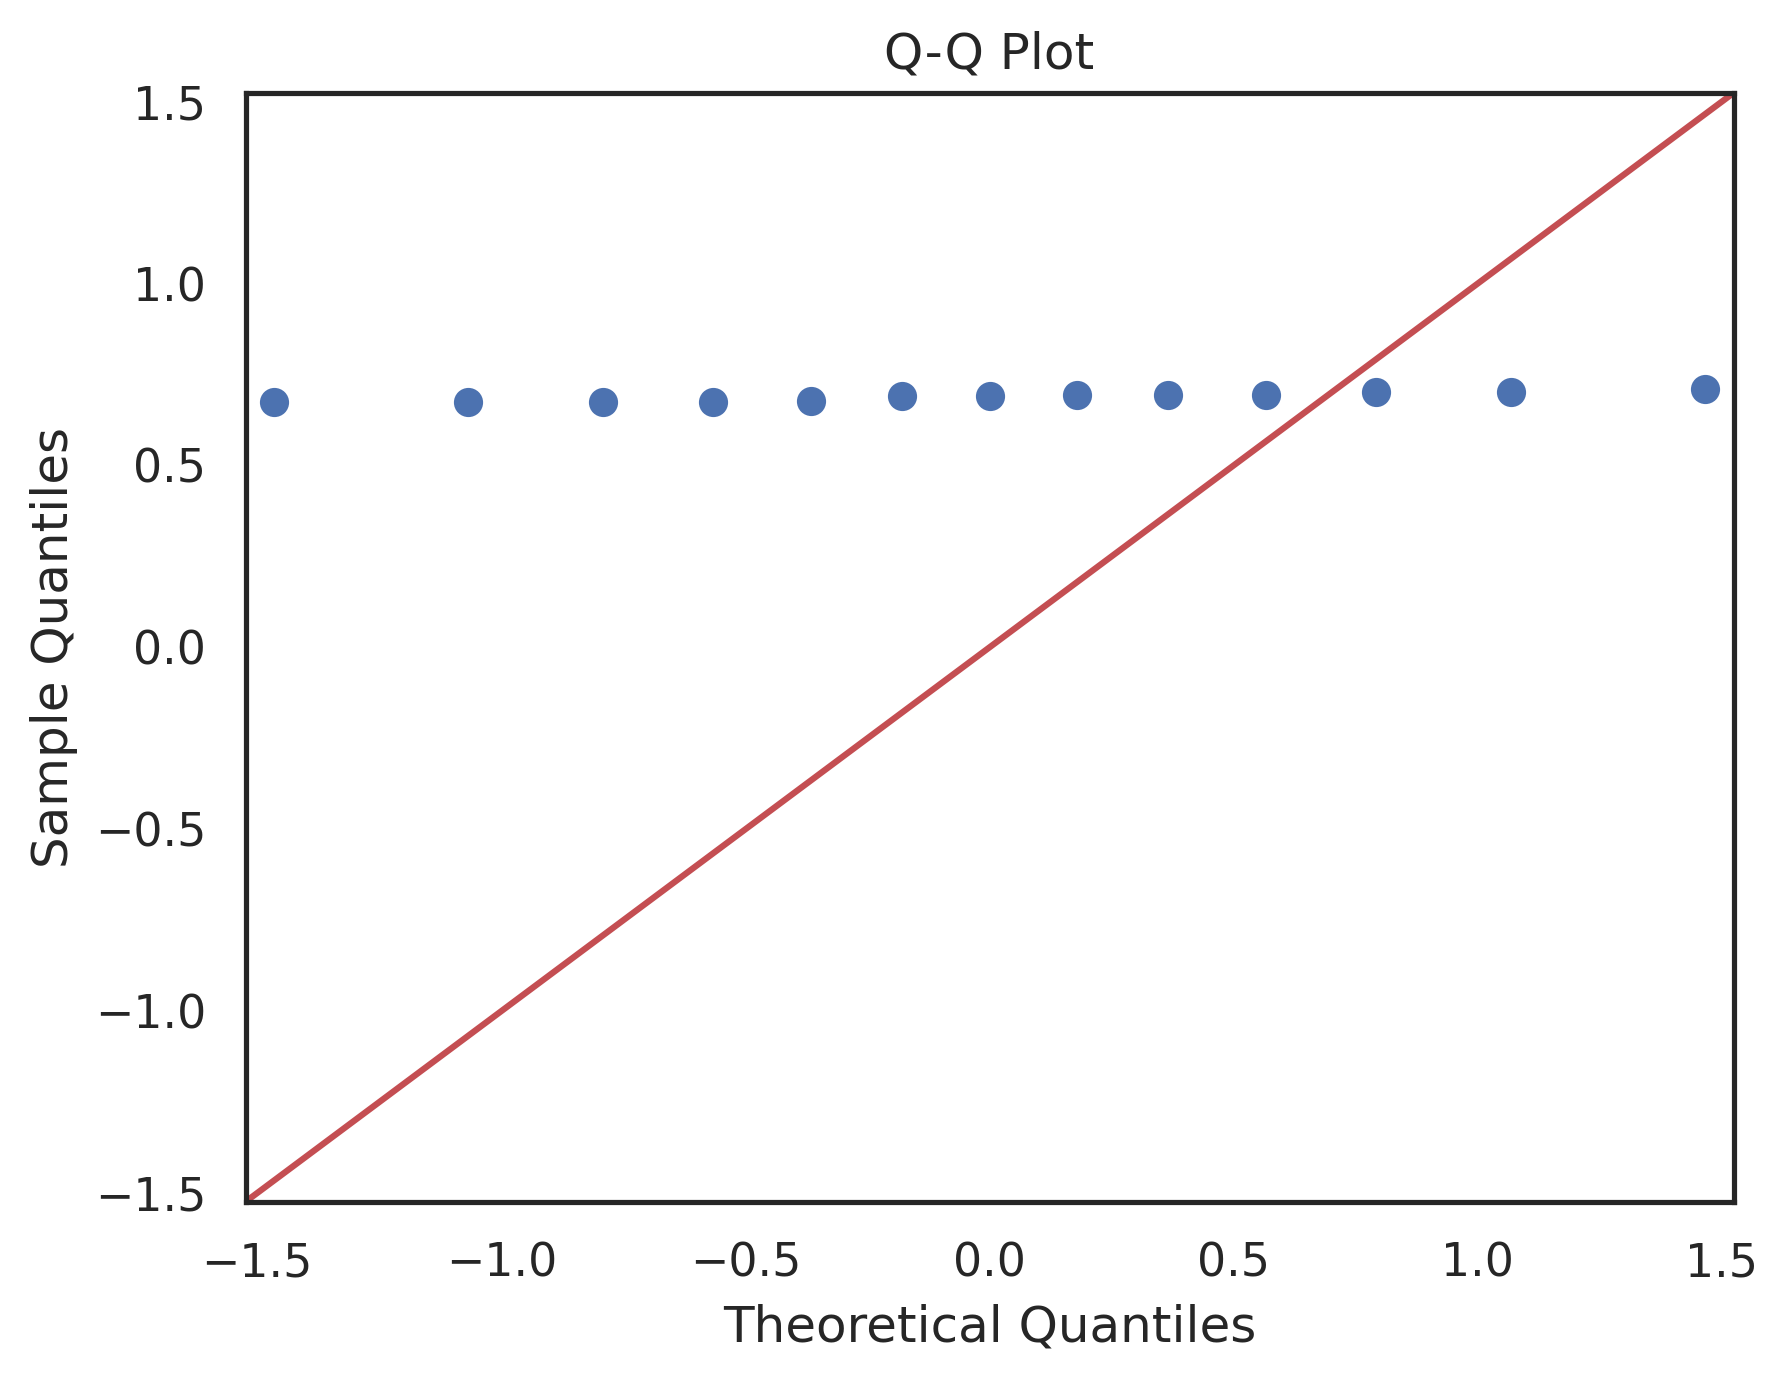

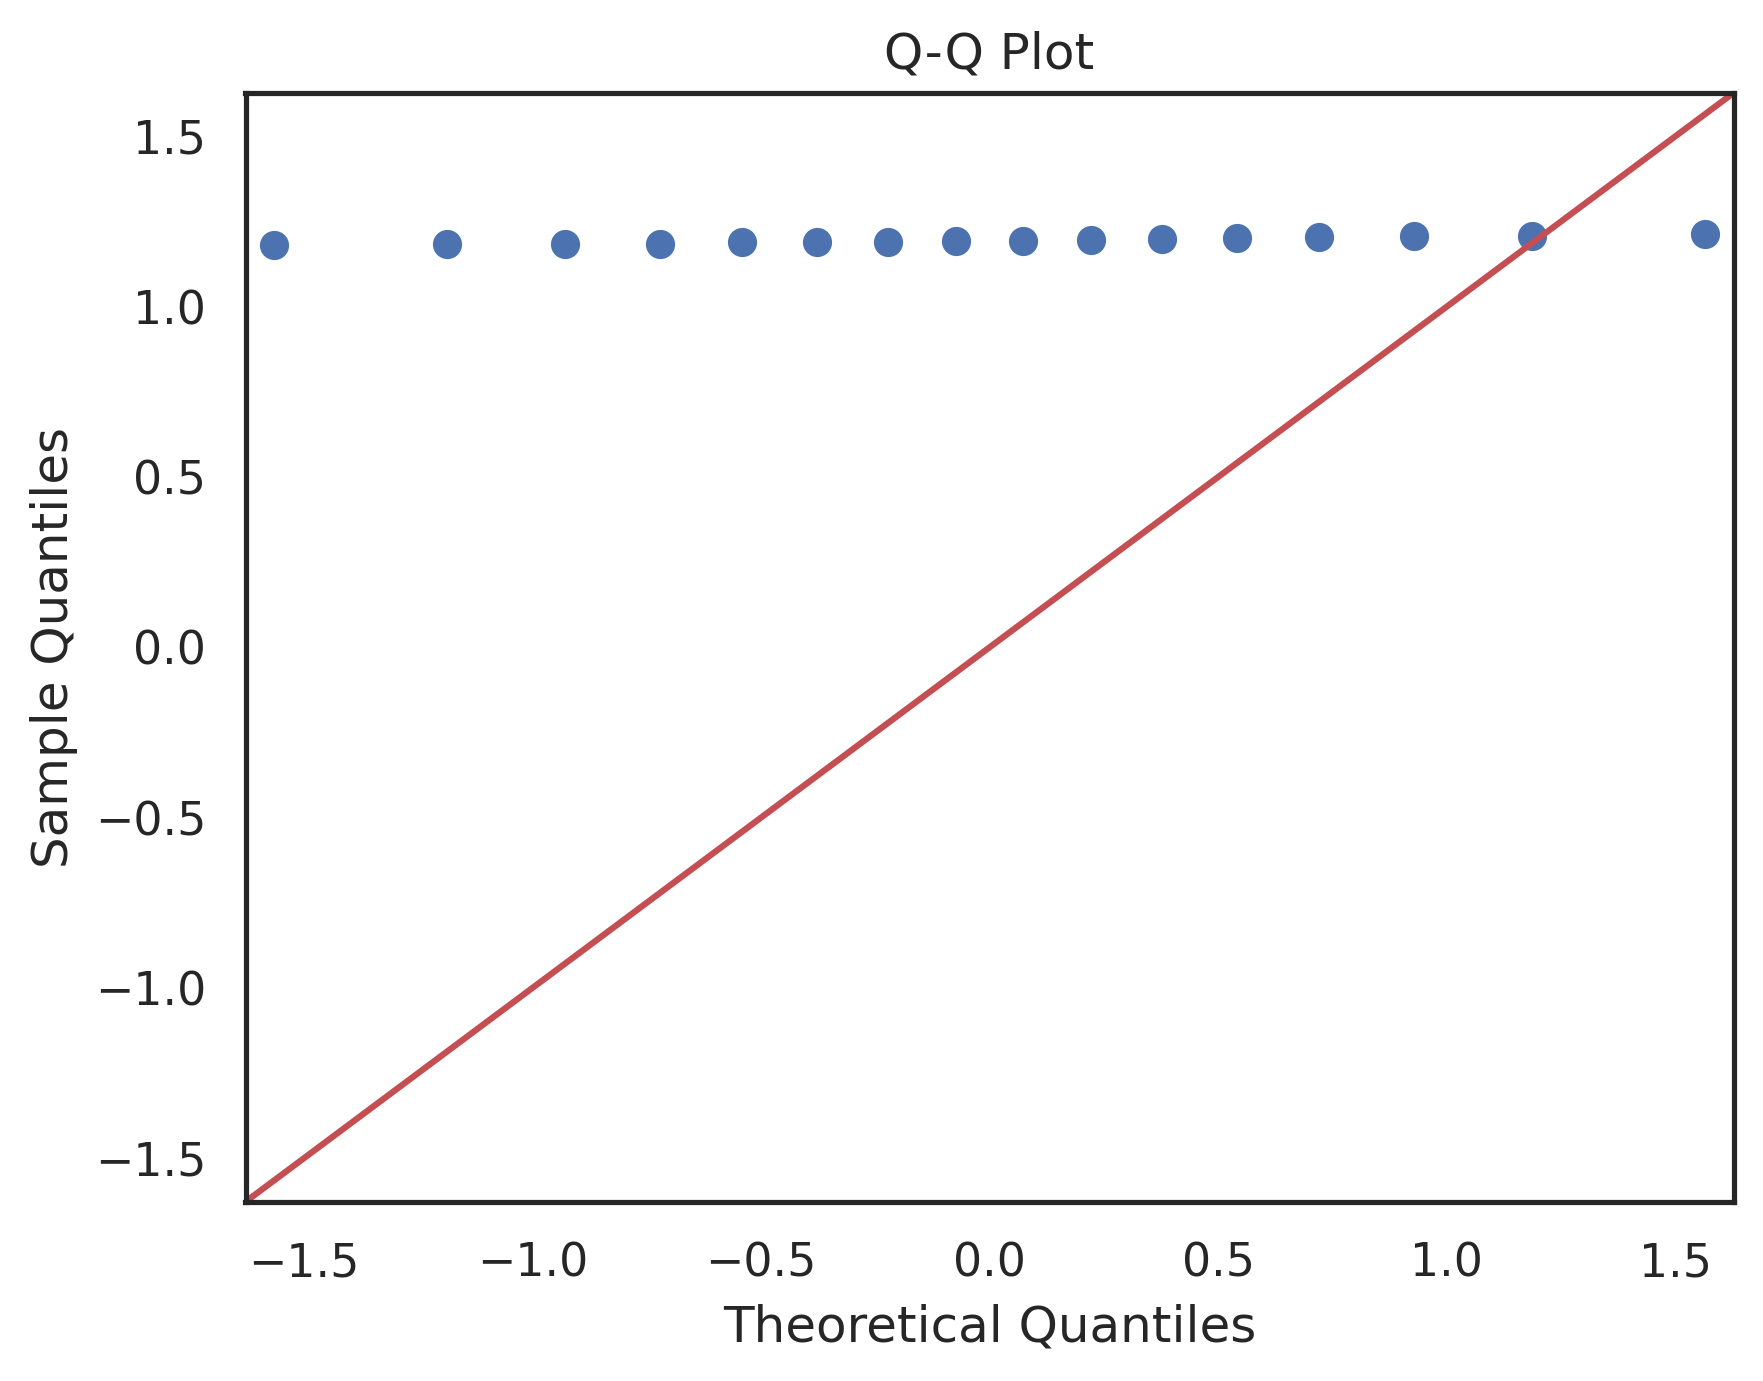

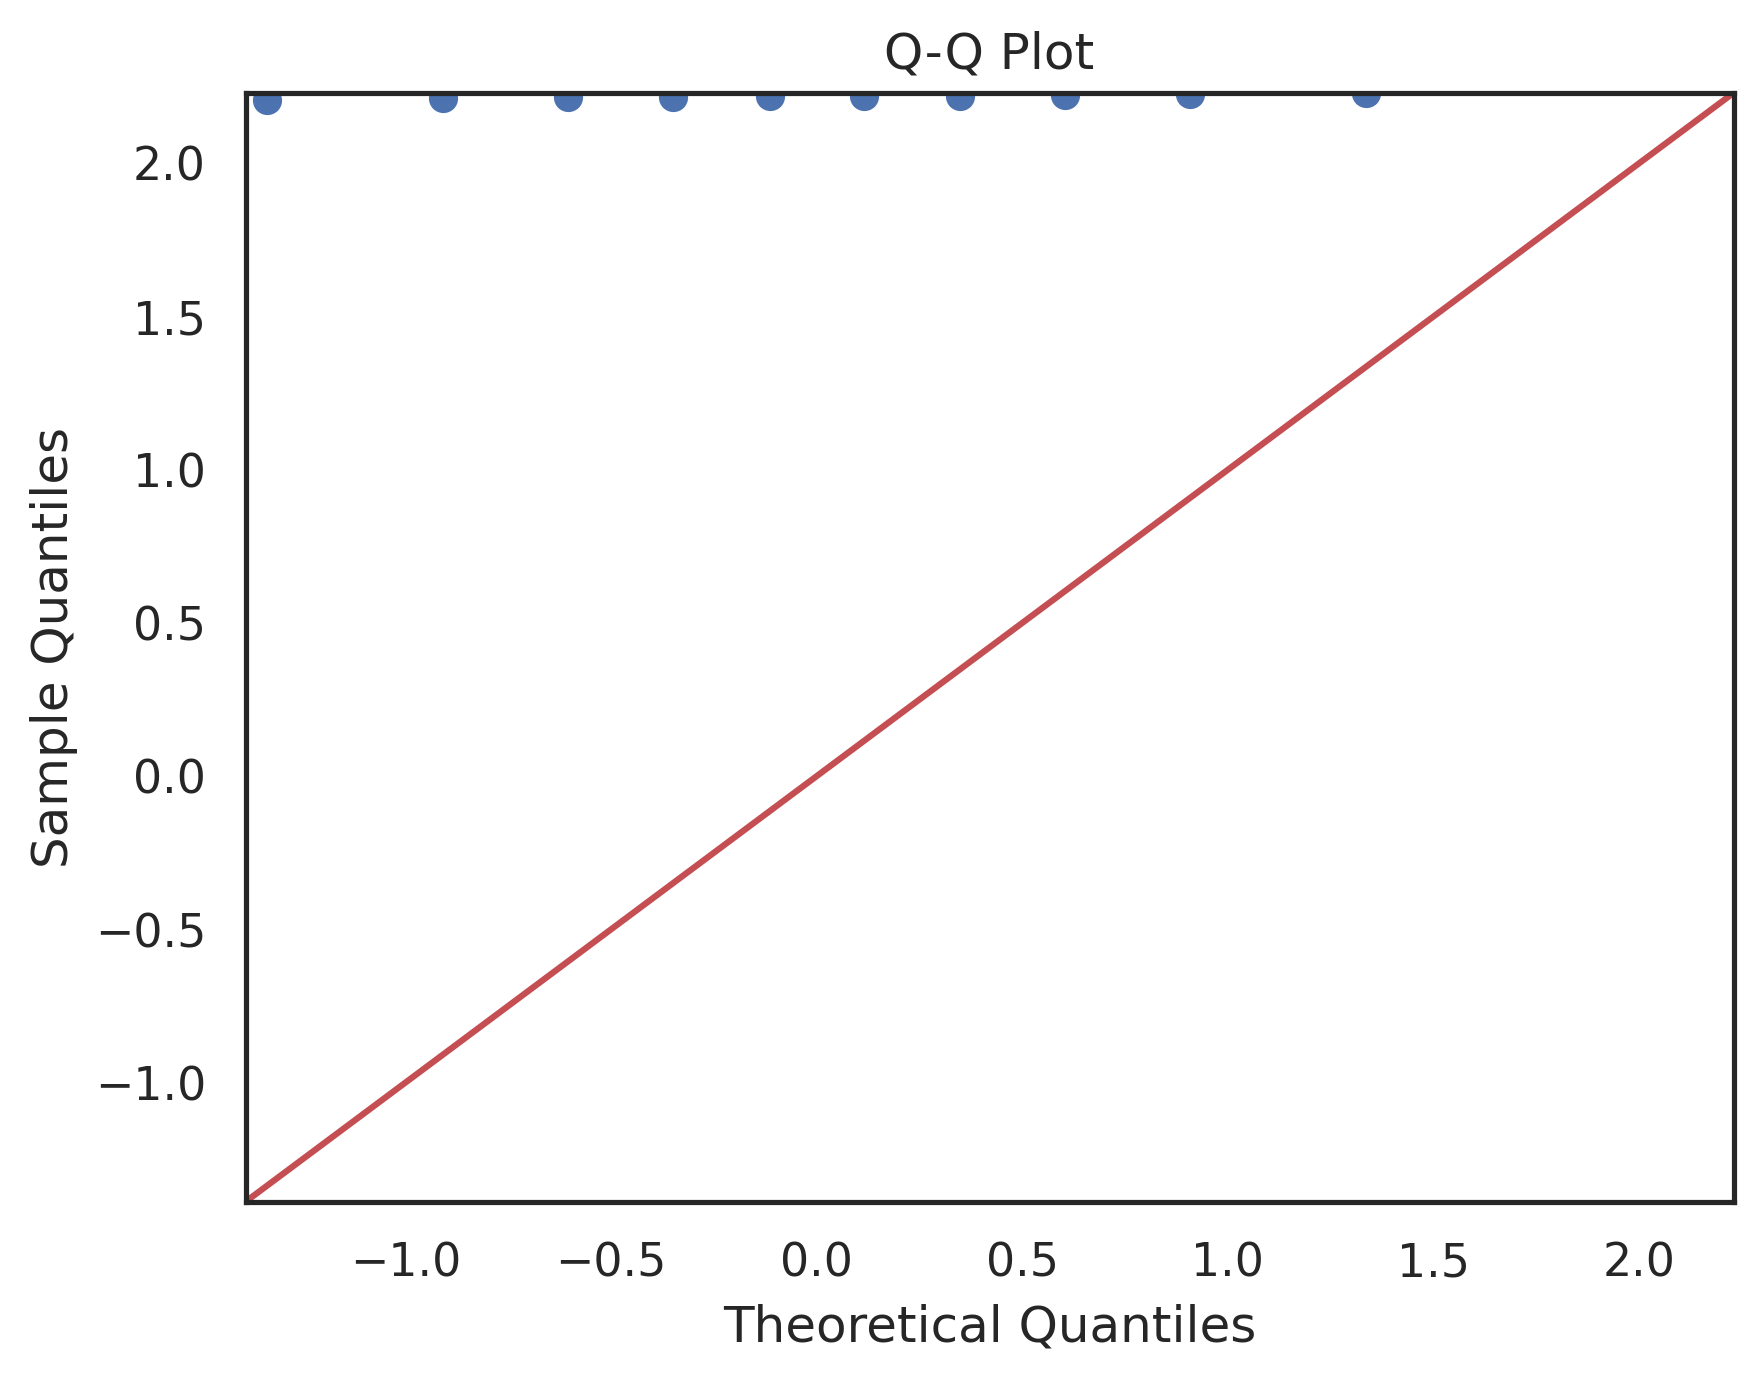

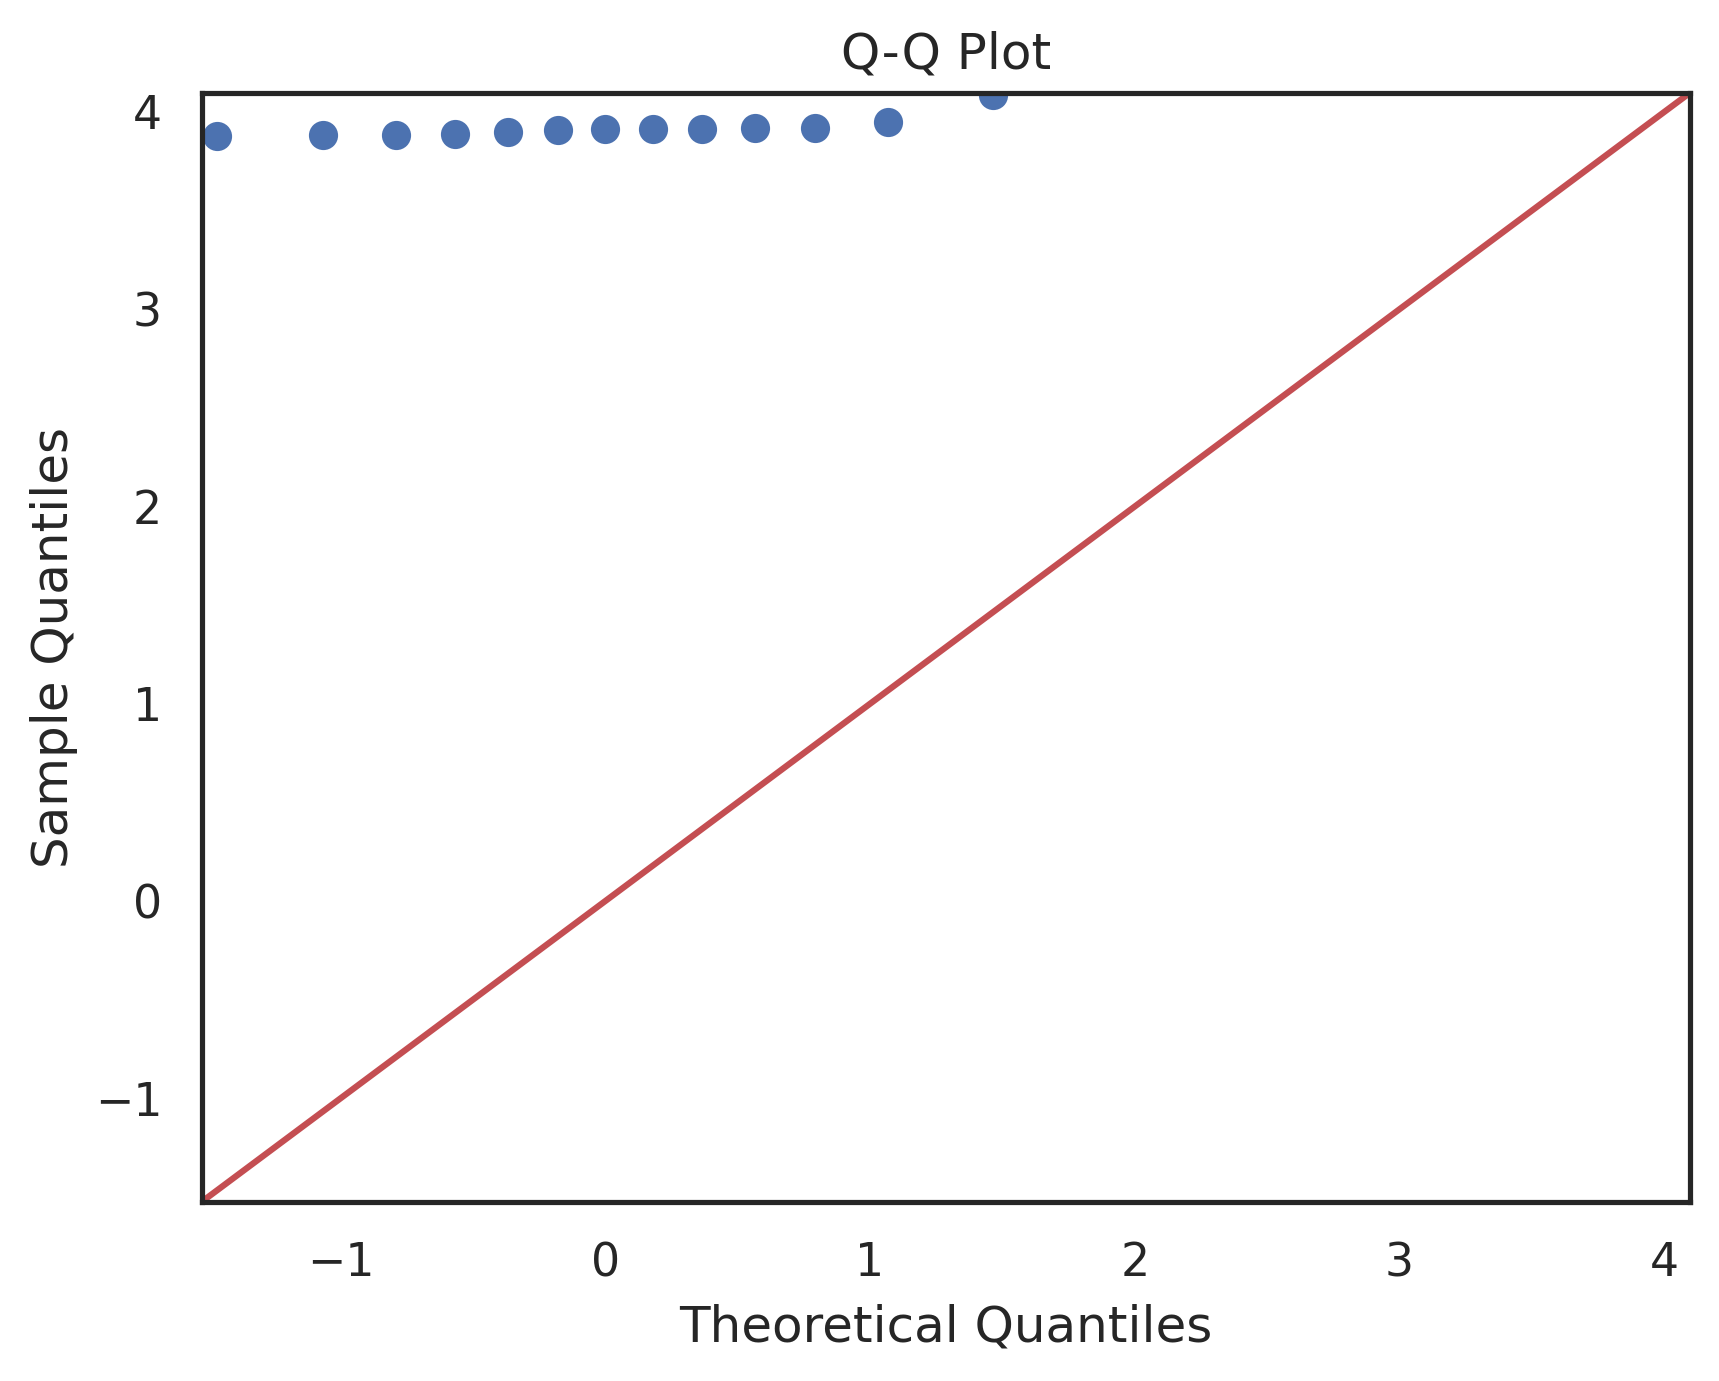

In [8]:
ps.generate_qq(dpp_mem, column=metric)

## Hypothesis Testing: Kruskal-Wallis

In [9]:
ps.test_hypothesis_kruskal(dpp_mem, column=metric)

(47.575471698113205, 2.621838394439671e-10)

## Effect Size: Cliff's Delta

In [10]:
ps.calc_cliffs_delta(dpp_mem, column=metric)

,CPUS-GROUPS,Value,Result
0,"(4, 8)",-1.0,large
1,"(8, 16)",-1.0,large
2,"(16, 32)",-1.0,large


## Effect Size: Percentage Improvement

In [11]:
ps.calc_groups_improvement(dpp_mem, column=metric)

,CPU-GROUPS,Mean Improvement,Median Improvement,Mean Delta,Median Delta
0,"(4, 8)",-42.361835,-42.029505,-0.505994,-0.501412
1,"(8, 16)",-46.177599,-46.262956,-1.024800,-1.027070
2,"(16, 32)",-43.380518,-43.300067,-1.700343,-1.695402
3,"(4, 32)",-82.435366,-82.337046,-3.231137,-3.223884


# Docking Antibody-Antigen Memory Analysis 

In [12]:
daa = pd.read_csv('./data/clean/data_daa.csv')
daa_mem = daa[['AveRSS', 'NCPUS']]

In [13]:
#daa_mem = ps.remove_outliers_cpus(daa_mem, column=metric)

# Descriptive Analysis

In [14]:
for x in [4, 8, 16, 32]:
    group = ps.get_group(daa_mem, ncpus=x)
    print(group.describe())

          AveRSS  NCPUS
count  12.000000   12.0
mean    1.488097    4.0
std     0.068465    0.0
min     1.456736    4.0
25%     1.459764    4.0
50%     1.467566    4.0
75%     1.480960    4.0
max     1.702840    4.0
          AveRSS  NCPUS
count  14.000000   14.0
mean    2.669390    8.0
std     0.197956    0.0
min     2.595208    8.0
25%     2.616508    8.0
50%     2.622668    8.0
75%     2.623561    8.0
max     3.356084    8.0
          AveRSS  NCPUS
count  10.000000   10.0
mean    4.903372   16.0
std     0.016867    0.0
min     4.879384   16.0
25%     4.892020   16.0
50%     4.904292   16.0
75%     4.911416   16.0
max     4.929936   16.0
          AveRSS  NCPUS
count  11.000000   11.0
mean    9.472577   32.0
std     0.041204    0.0
min     9.359000   32.0
25%     9.467076   32.0
50%     9.480864   32.0
75%     9.488274   32.0
max     9.514128   32.0


## Boxplots

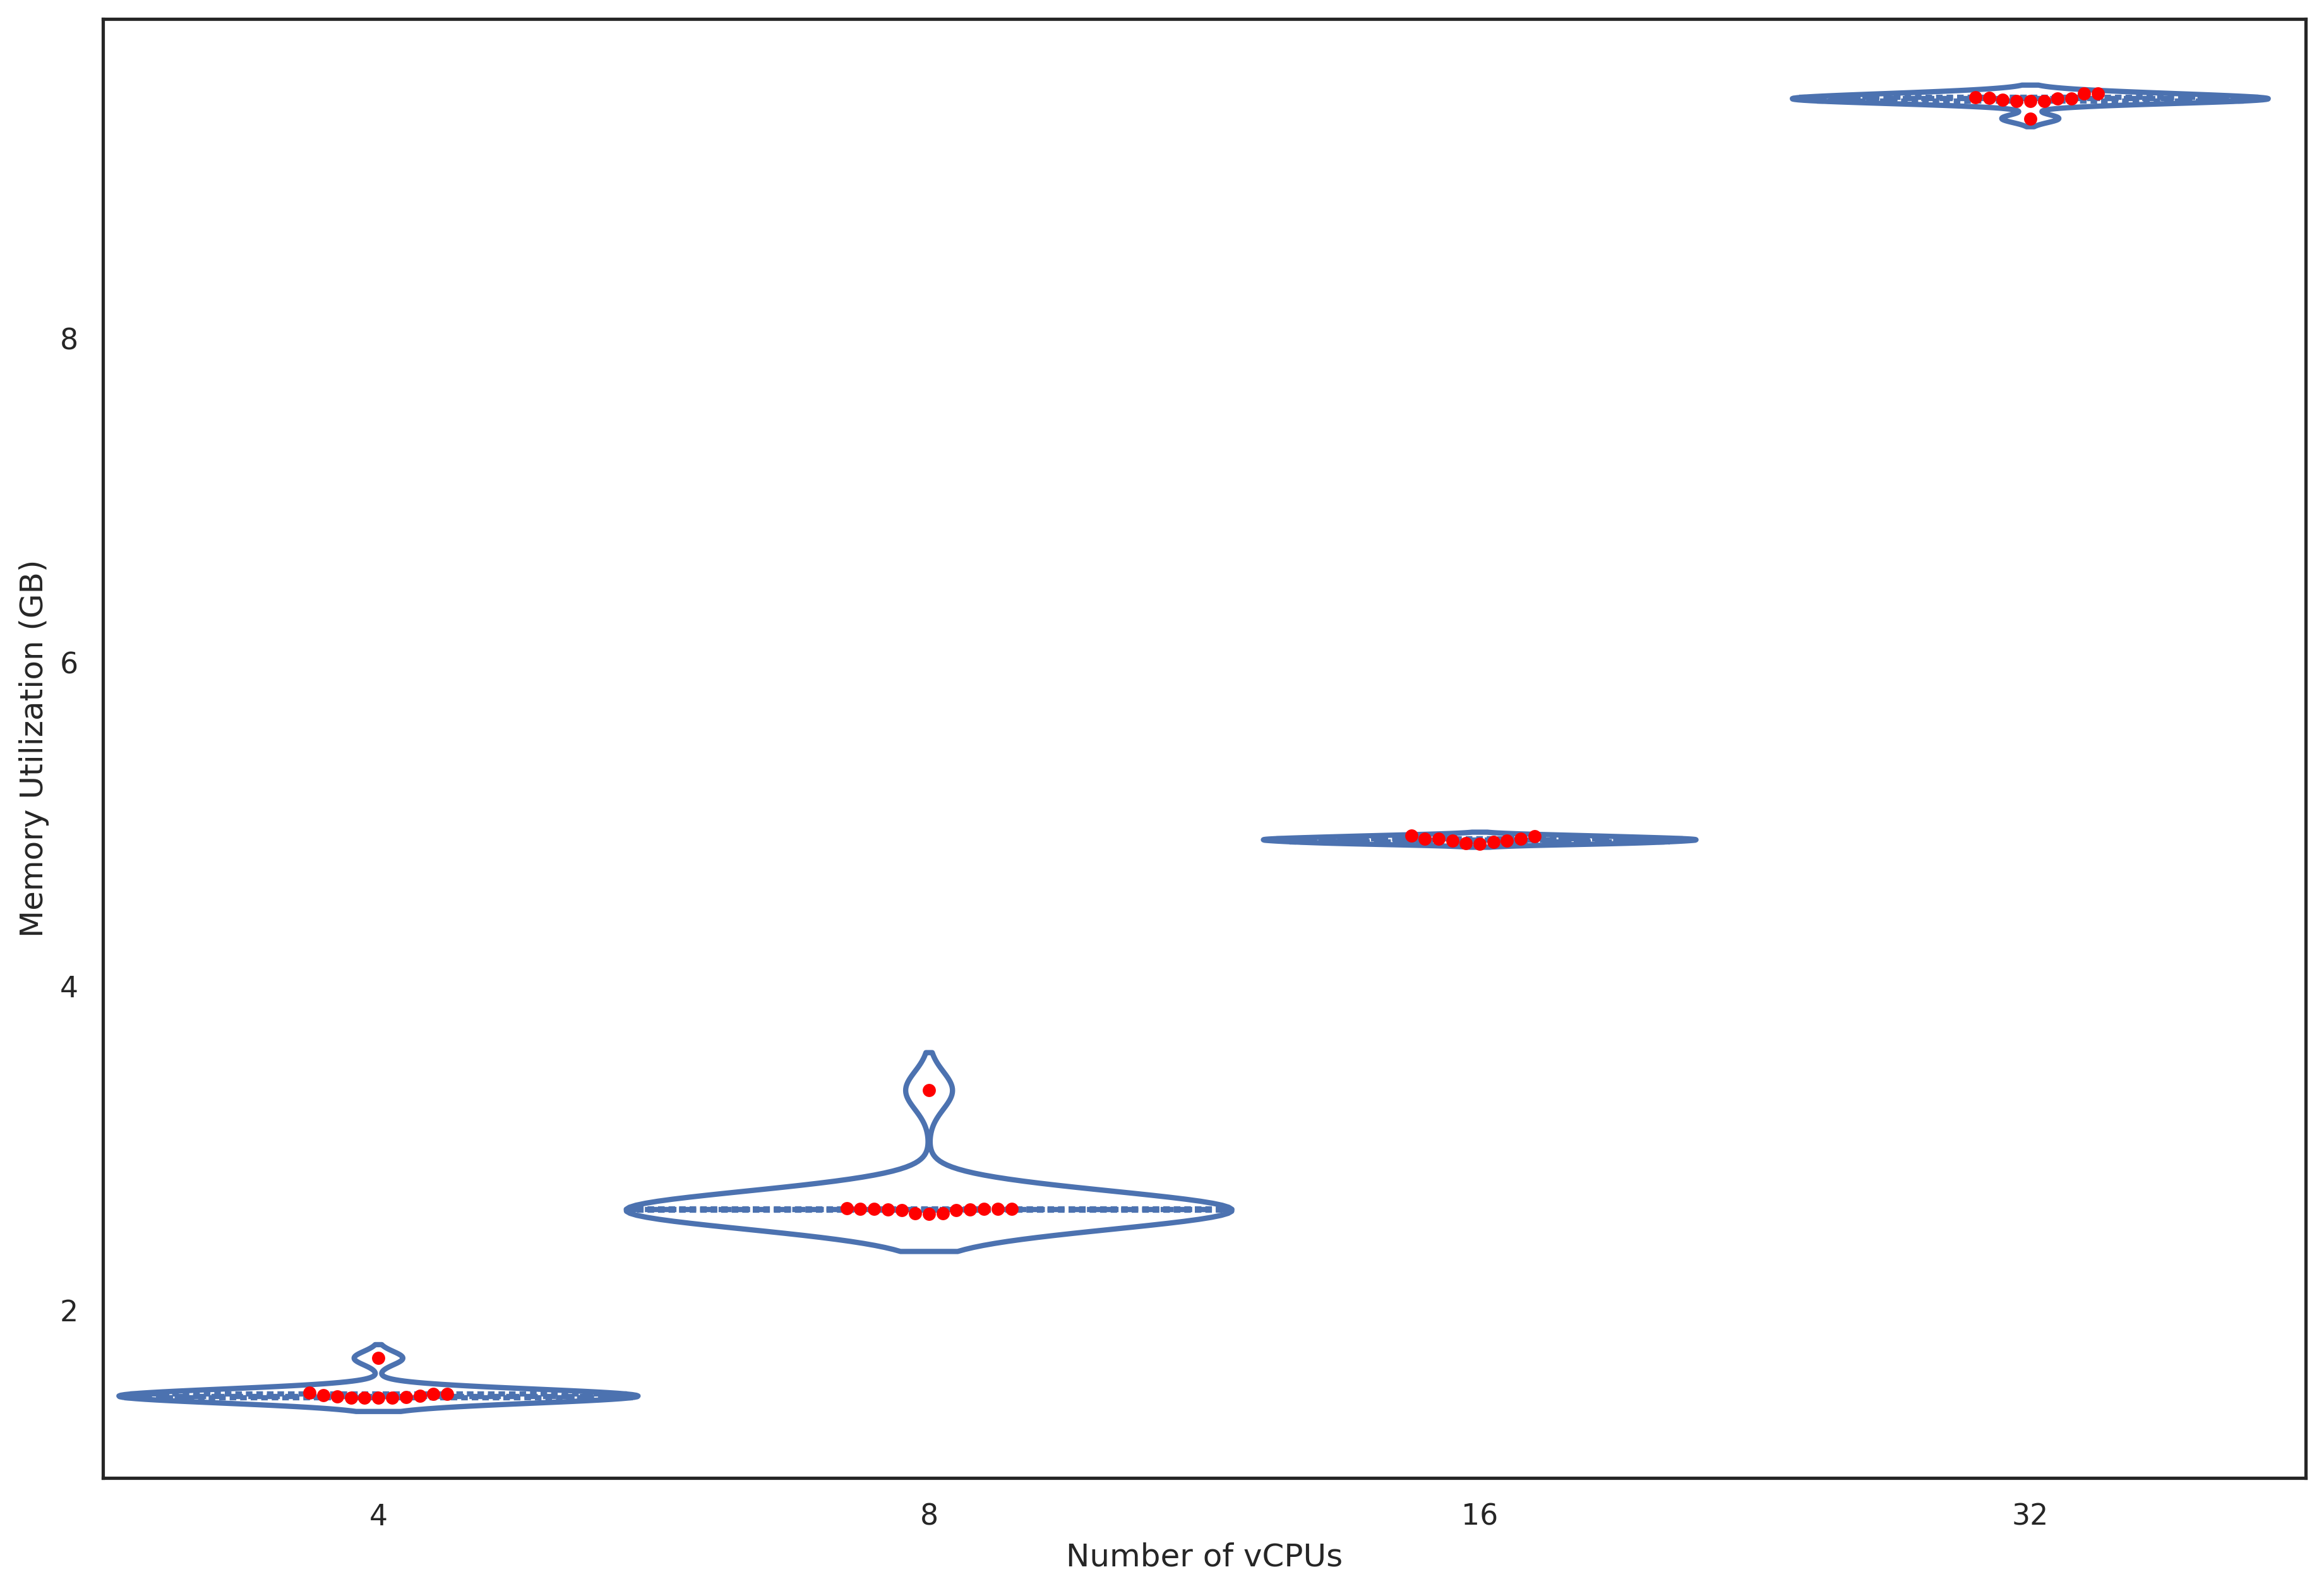

In [15]:
da.show_boxplot(
    daa_mem, "Average Memory (Resident Set Size) of DAA Workflow at Varying Parallelism Degrees", metric=metric,
    x_label="Number of vCPUs", y_label="Memory Utilization (GB)", store=True
)

## Normality Test: Shapiro-Wilk and QQ-Plots

In [21]:
normality = ps.test_normality(daa_mem, column=metric)
print(normality)

   NCPUS      STAT        PVALUE
0      4  0.467229  1.023311e-05
1      8  0.344362  4.463961e-07
2     16  0.960035  7.862677e-01
3     32  0.725114  9.867012e-04


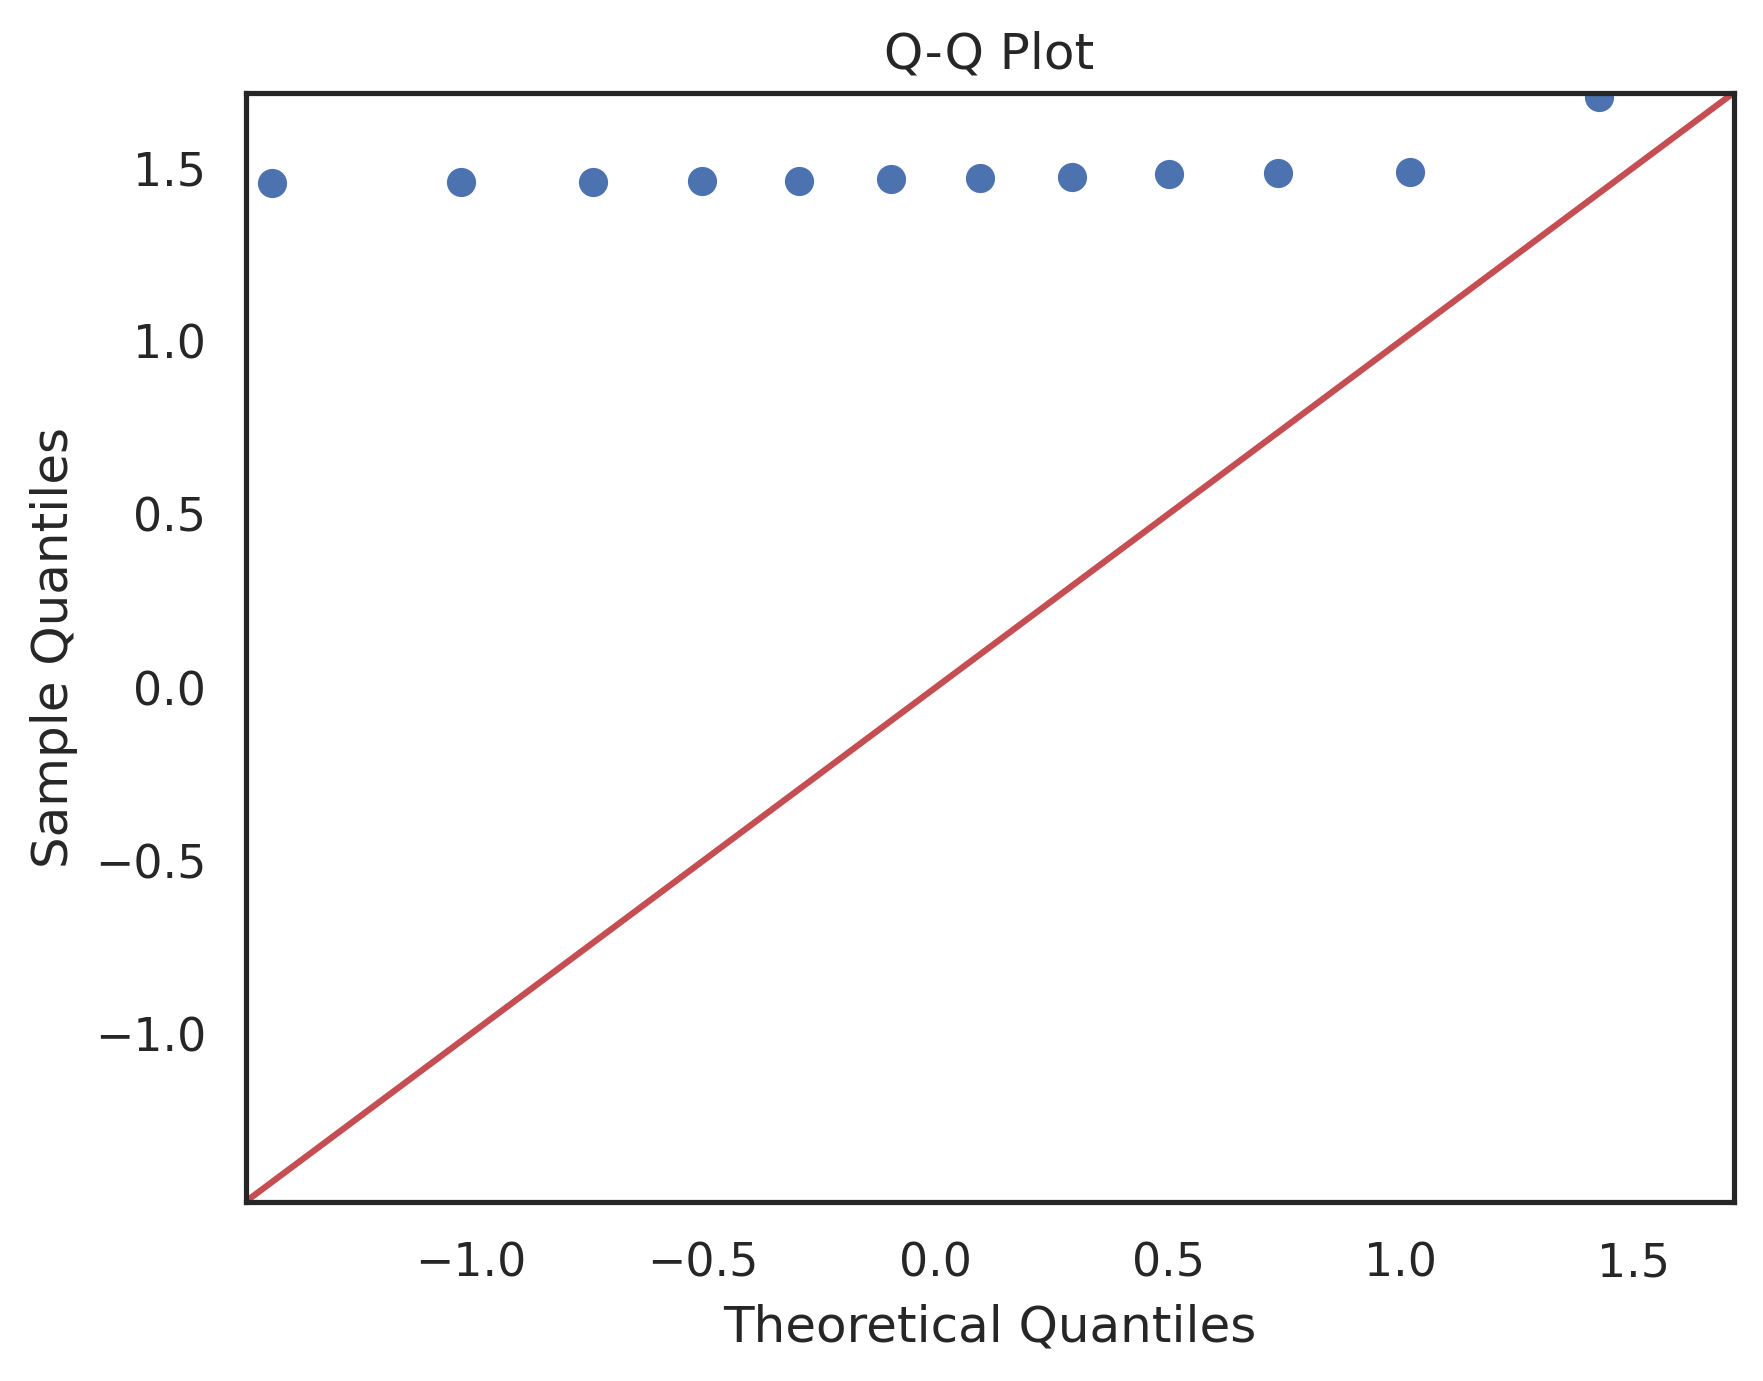

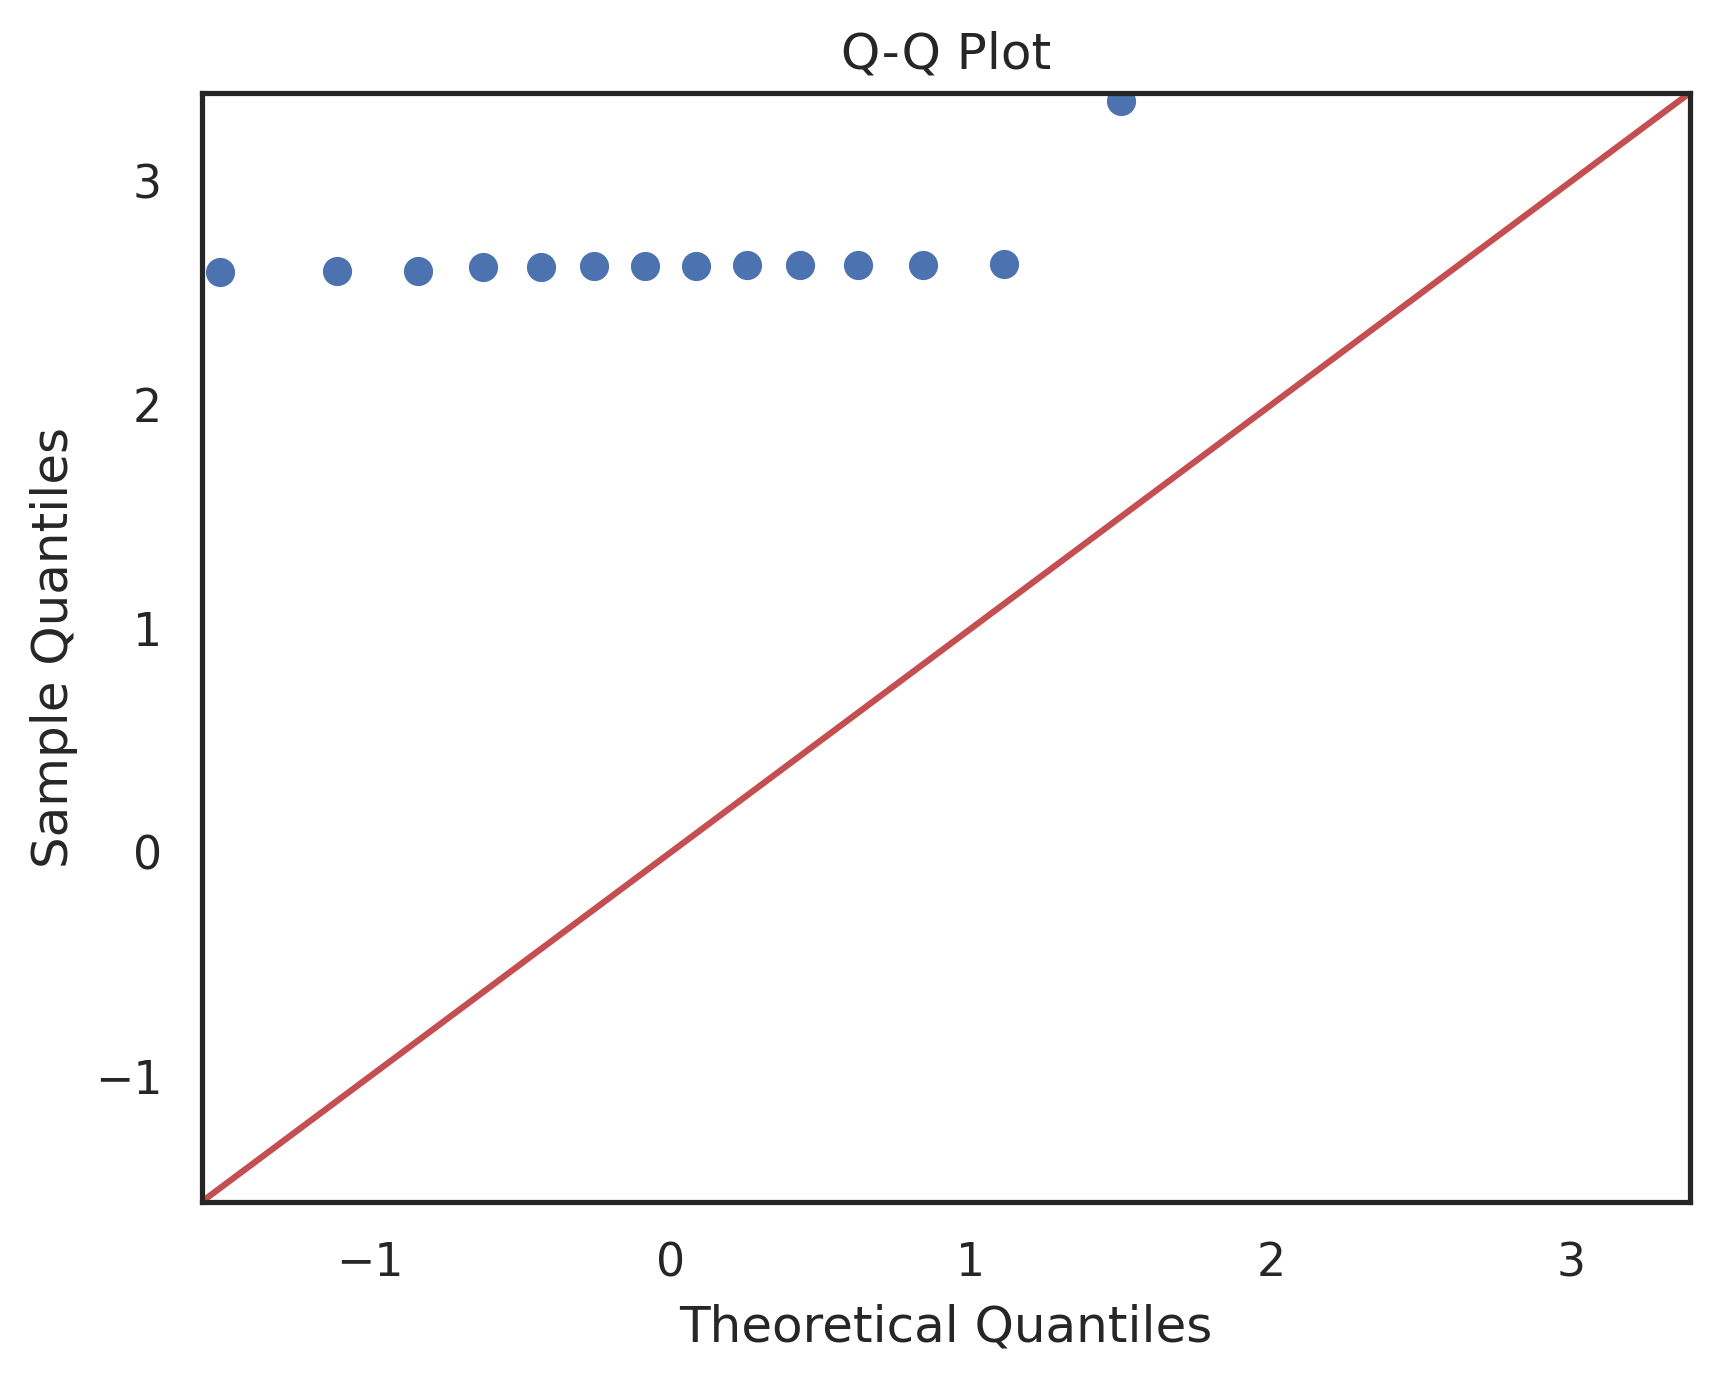

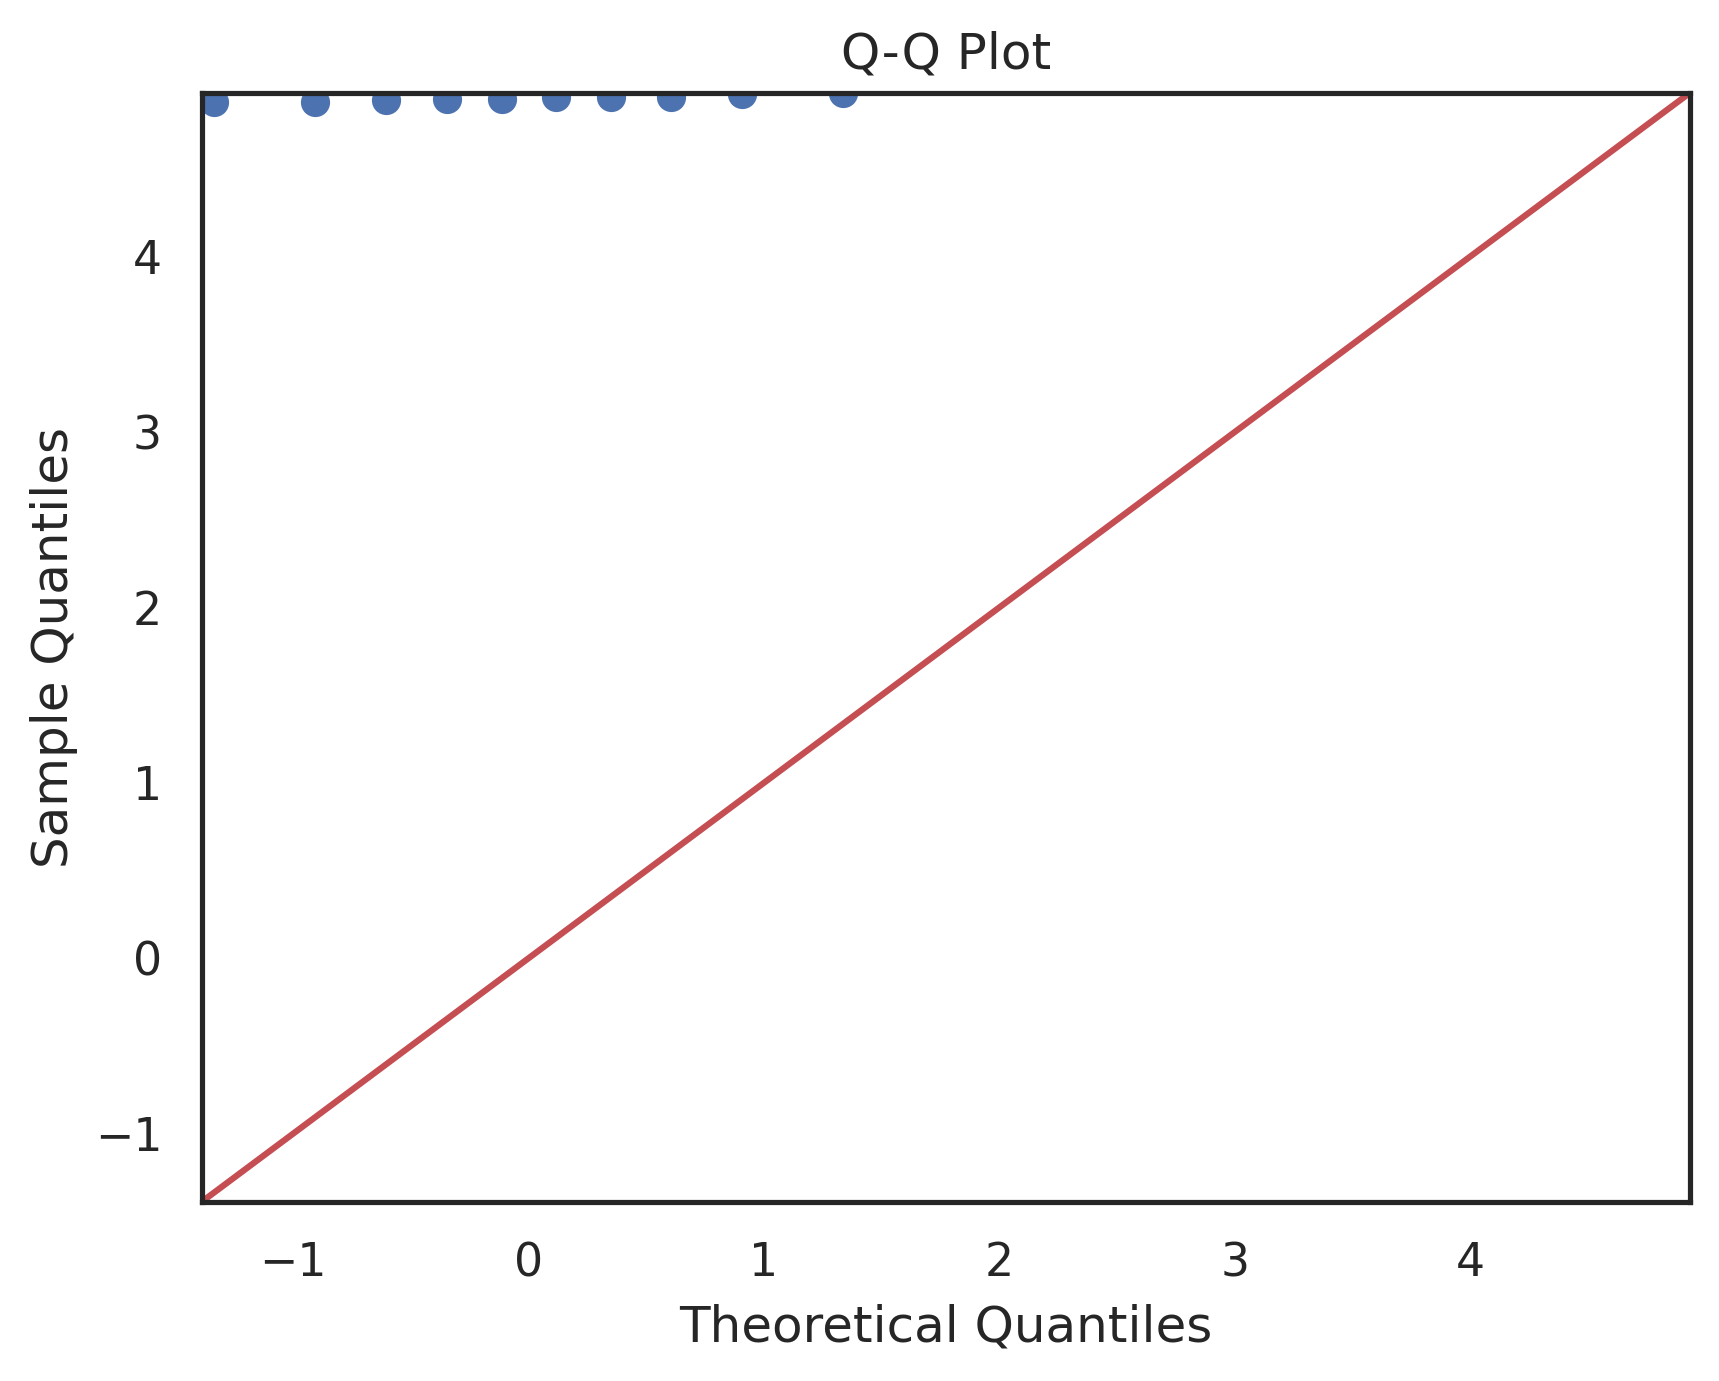

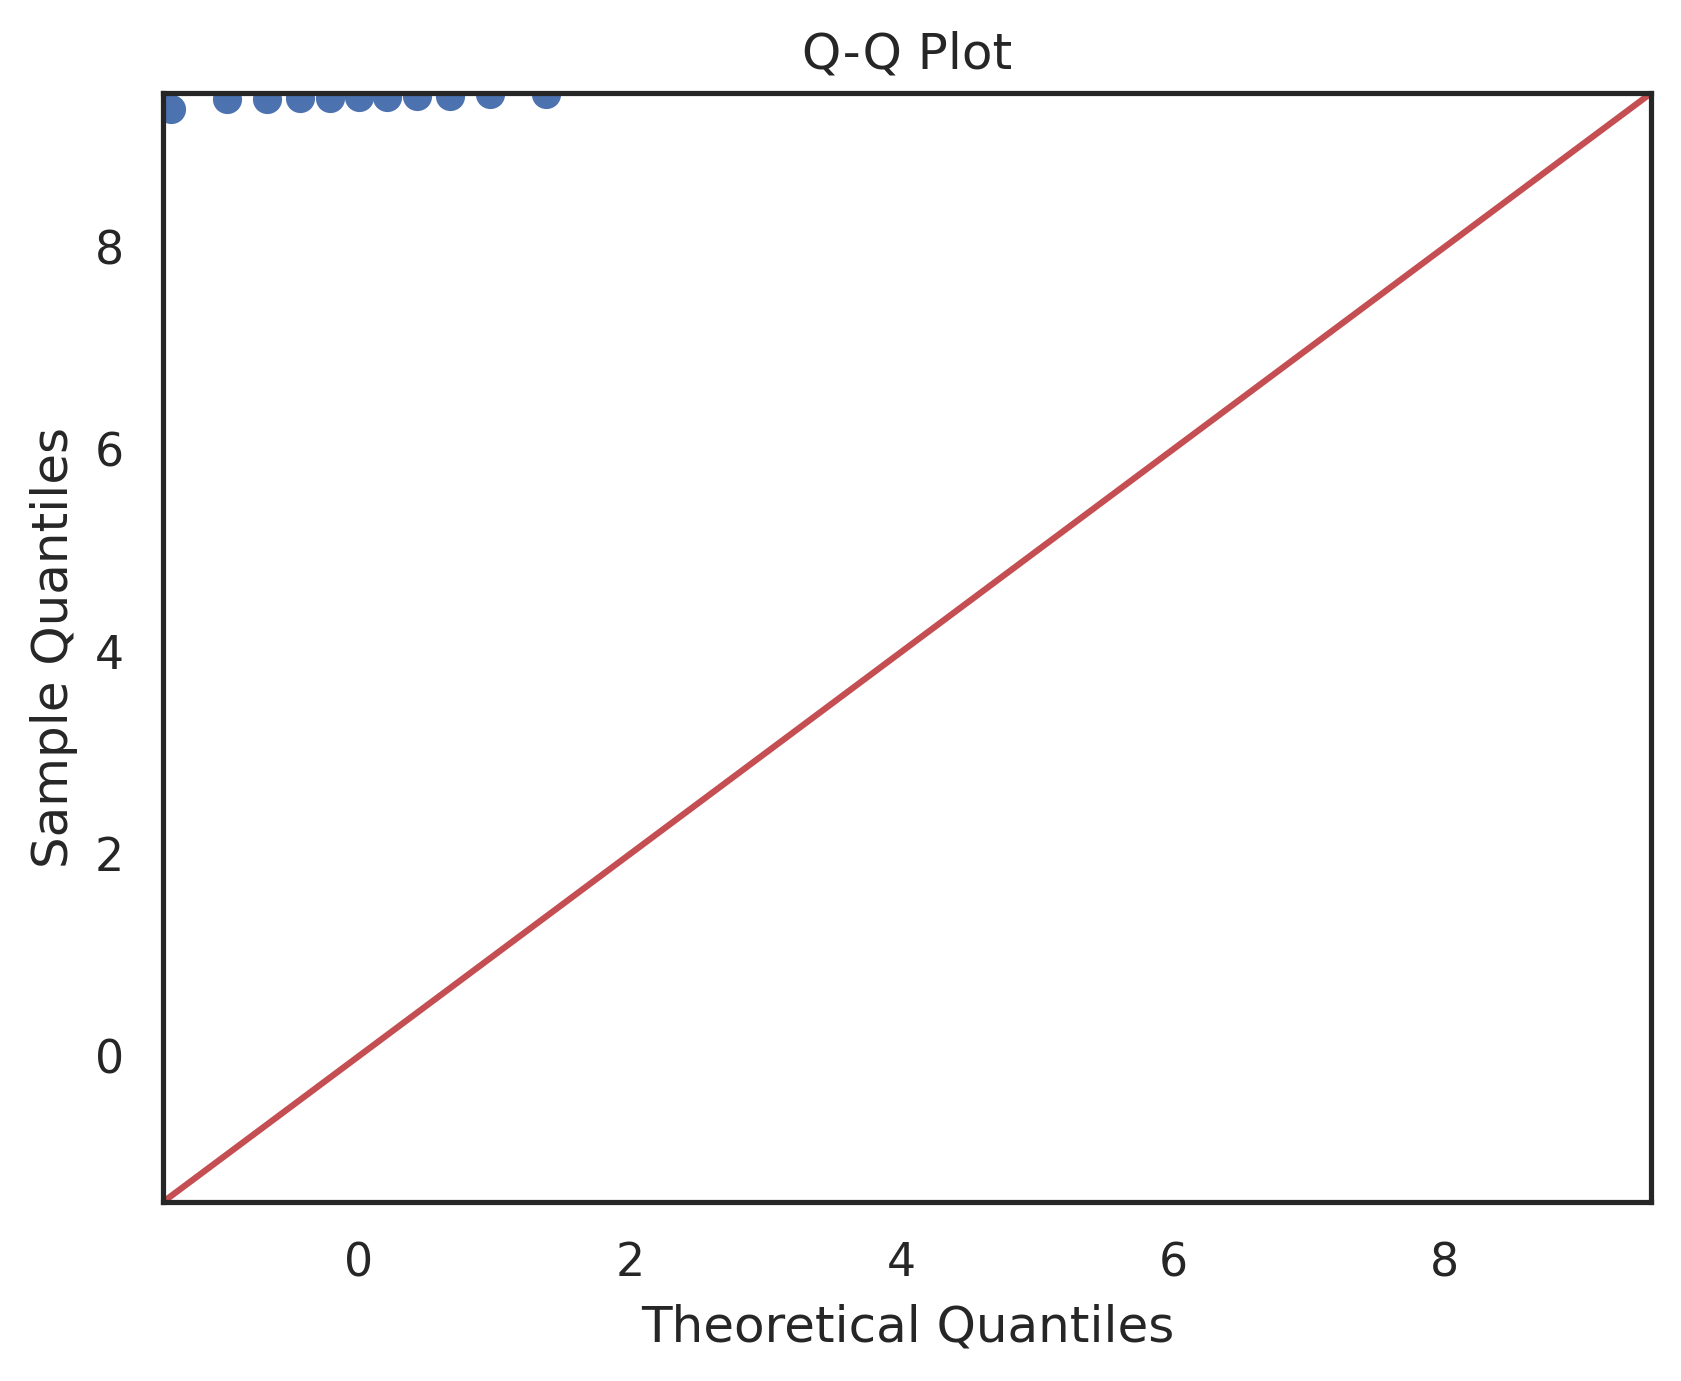

In [17]:
ps.generate_qq(daa_mem, column=metric)

## Hypothesis Testing: Kruskal-Wallis

In [18]:
ps.test_hypothesis_kruskal(daa_mem, column=metric)

(43.00531914893617, 2.454610623477107e-09)

## Effect Size: Cliff's Delta

In [19]:
ps.calc_cliffs_delta(daa_mem, column=metric)

,CPUS-GROUPS,Value,Result
0,"(4, 8)",-1.0,large
1,"(8, 16)",-1.0,large
2,"(16, 32)",-1.0,large


## Effect Size: Percentage Improvement

In [20]:
ps.calc_groups_improvement(daa_mem, column=metric)

,CPU-GROUPS,Mean Improvement,Median Improvement,Mean Delta,Median Delta
0,"(4, 8)",-44.253287,-44.043013,-1.181293,-1.155102
1,"(8, 16)",-45.560111,-46.523005,-2.233982,-2.281624
2,"(16, 32)",-48.236133,-48.271677,-4.569205,-4.576572
3,"(4, 32)",-84.290469,-84.520757,-7.984479,-8.013298
